In [26]:
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Exploration - Large Products Dataset (v3)


This notebook explores the new large skincare product dataset (products_dataset_raw.csv with ~50,969 entries).

Dataset Name: SkinSAFE Skincare Products (50,000+)

Kaggle Link: https://www.kaggle.com/datasets/kazireyazulhasan/skinsafe-skincare-db-50000-products?resource=download

In [27]:
BASE_DIR = Path().resolve()
DATASET_PATH = BASE_DIR / ".." / "data" / "raw" / "products_dataset_raw.csv"
DATASET_PATH = DATASET_PATH.resolve()

df = pd.read_csv(DATASET_PATH)
df.head()

,product_name,brand,usage_type,category,ingredients,image_url,product_url
0,No7 Hydra Luminous Aqua Release Skin Perfector...,No7,Face,Tinted Moisturizers,"Propylene Glycol, Alcohol Denat, Anhydroxylito...",https://cdn1.skinsafeproducts.com/photo/E84797...,https://www.skinsafeproducts.com/no7-hydra-lum...
1,"Tower 28 SOS Daily Rescue Facial Spray, 4 fl o...",Tower 28,Face,Spray Moisturizer,"Hypochlorous Acid, Sodium Chloride, Water",https://cdn1.skinsafeproducts.com/photo/488026...,https://www.skinsafeproducts.com/tower-28-sos-...
2,"Clinique Takes the Day Off Cleansing Oil, 6.7 ...",Clinique,Facial Cleansers,Facial Cleansing Oil,"Bht, Caprylyl Glycol, Cetyl Ethylhexanoate, Gl...",https://cdn1.skinsafeproducts.com/photo/53EEB4...,https://www.skinsafeproducts.com/clinique-take...
3,"Necessaire The Body Lotion, Fragrance Free, 15...",Necessaire,Body,Lotions,"Aqua/Water/Eau, Caprylhydroxamic Acid, Capryli...",https://cdn1.skinsafeproducts.com/photo/D9ADD5...,https://www.skinsafeproducts.com/necessaire-th...
4,Paula’s Choice Resist Weightless Advanced Repa...,Paula's Choice,Toners & Astringents,Toners,"Acetyl Glucosamine, Adenosine, Butylene Glycol...",https://cdn1.skinsafeproducts.com/photo/2A9B12...,https://www.skinsafeproducts.com/paula-s-choic...


### Overview

In [28]:
print("=== Dataset Overview ===")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumns:")
for col in df.columns:
    print(f" - {col} ({df[col].dtype})")

=== Dataset Overview ===
Number of rows: 50,969
Number of columns: 7
Memory usage: 55.31 MB

Columns:
 - product_name (object)
 - brand (object)
 - usage_type (object)
 - category (object)
 - ingredients (object)
 - image_url (object)
 - product_url (object)


In [29]:
print("\n=== Missing Values ===")
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({"count": missing_counts, "percent": missing_pct})
display(missing_df)

dupes = df.duplicated(subset=[col for col in df.columns if 'name' in col.lower() or 'id' in col.lower()]).sum() if any('name' in col.lower() or 'id' in col.lower() for col in df.columns) else 0
print(f"\nDuplicate rows (on key columns): {dupes}")


=== Missing Values ===


,count,percent
product_name,0,0.0
brand,0,0.0
usage_type,0,0.0
category,0,0.0
ingredients,0,0.0
image_url,0,0.0
product_url,0,0.0



Duplicate rows (on key columns): 623


### Columns

#### Categorical Columns Overview

In [30]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("\n=== Categorical Columns ===")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"\n{col}:")
    print(f"  Unique values: {unique_count}")
    print(f"  Top values:")
    print(df[col].value_counts().head(5))


=== Categorical Columns ===

product_name:
  Unique values: 50346
  Top values:
product_name
Medik8 Advanced Night Rejuvenating Eye Cream, 0.5 fl oz/15 mL                       3
Olay Quench Ultra Moisture Lotion with Shea Butter Lotion Women 8.4 Ounce           3
Honest Beauty Magic Balm, Magic, 0.17 oz                                            2
Honest Beauty Organic Facial Oil, 1.0 Fluid Ounce                                   2
Bath & Body Works Gentle Foam Hand Soap, Vanilla Bean, 8 fl oz/259 mL, Pack Of 2    2
Name: count, dtype: int64

brand:
  Unique values: 6959
  Top values:
brand
Bath & Body Works    2072
Neutrogena            615
Olay                  545
Nivea                 442
Clinique              436
Name: count, dtype: int64

usage_type:
  Unique values: 21
  Top values:
usage_type
Body                8745
Skin Treatments     8125
Face                7952
Cleansers           7555
Facial Cleansers    3605
Name: count, dtype: int64

category:
  Unique values: 101
  T

#### Numeric Columns Overview

In [31]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\n=== Numeric Columns Statistics ===")
if len(numeric_cols) > 0:
    display(df[numeric_cols].describe())
else:
    print("No numeric columns found in the dataset.")


=== Numeric Columns Statistics ===
No numeric columns found in the dataset.


### Data Quality Checks

In [32]:
print("\n=== Data Quality Checks ===")
print(f"Total null cells: {df.isnull().sum().sum()}")
print(f"Total duplicate rows: {df.duplicated().sum()}")

# Check for empty strings in object columns
print("\nEmpty string check in object columns:")
for col in categorical_cols:
    empty_count = (df[col].astype(str).str.strip() == '').sum()
    if empty_count > 0:
        print(f"  {col}: {empty_count} empty values")


=== Data Quality Checks ===
Total null cells: 0
Total duplicate rows: 621

Empty string check in object columns:


### Text Column Analysis

In [33]:
# Analyze text columns for length and content patterns
print("\n=== Text Column Statistics ===")
for col in categorical_cols:
    if df[col].dtype == 'object':
        lengths = df[col].astype(str).str.len()
        print(f"\n{col}:")
        print(f"  Mean length: {lengths.mean():.1f} chars")
        print(f"  Median length: {lengths.median():.1f} chars")
        print(f"  Max length: {lengths.max()} chars")
        print(f"  Min length: {lengths.min()} chars")


=== Text Column Statistics ===

product_name:
  Mean length: 59.1 chars
  Median length: 58.0 chars
  Max length: 173 chars
  Min length: 11 chars

brand:
  Mean length: 10.7 chars
  Median length: 10.0 chars
  Max length: 46 chars
  Min length: 2 chars

usage_type:
  Mean length: 10.7 chars
  Median length: 9.0 chars
  Max length: 31 chars
  Min length: 4 chars

category:
  Mean length: 12.6 chars
  Median length: 9.0 chars
  Max length: 39 chars
  Min length: 4 chars

ingredients:
  Mean length: 519.5 chars
  Median length: 468.0 chars
  Max length: 5044 chars
  Min length: 4 chars

image_url:
  Mean length: 88.7 chars
  Median length: 89.0 chars
  Max length: 135 chars
  Min length: 86 chars

product_url:
  Mean length: 89.9 chars
  Median length: 89.0 chars
  Max length: 215 chars
  Min length: 38 chars


### Distribution Analysis

In [34]:
# Visualize distributions of key columns
if len(numeric_cols) > 0:
    fig, axes = plt.subplots(min(3, len(numeric_cols)), 1, figsize=(10, 4 * min(3, len(numeric_cols))))
    if len(numeric_cols) == 1:
        axes = [axes]
    elif len(numeric_cols) <= 3:
        axes = list(axes)
    else:
        axes = list(axes[:3])
    
    for idx, col in enumerate(numeric_cols[:3]):
        df[col].hist(bins=50, ax=axes[idx], edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns to visualize.")

No numeric columns to visualize.


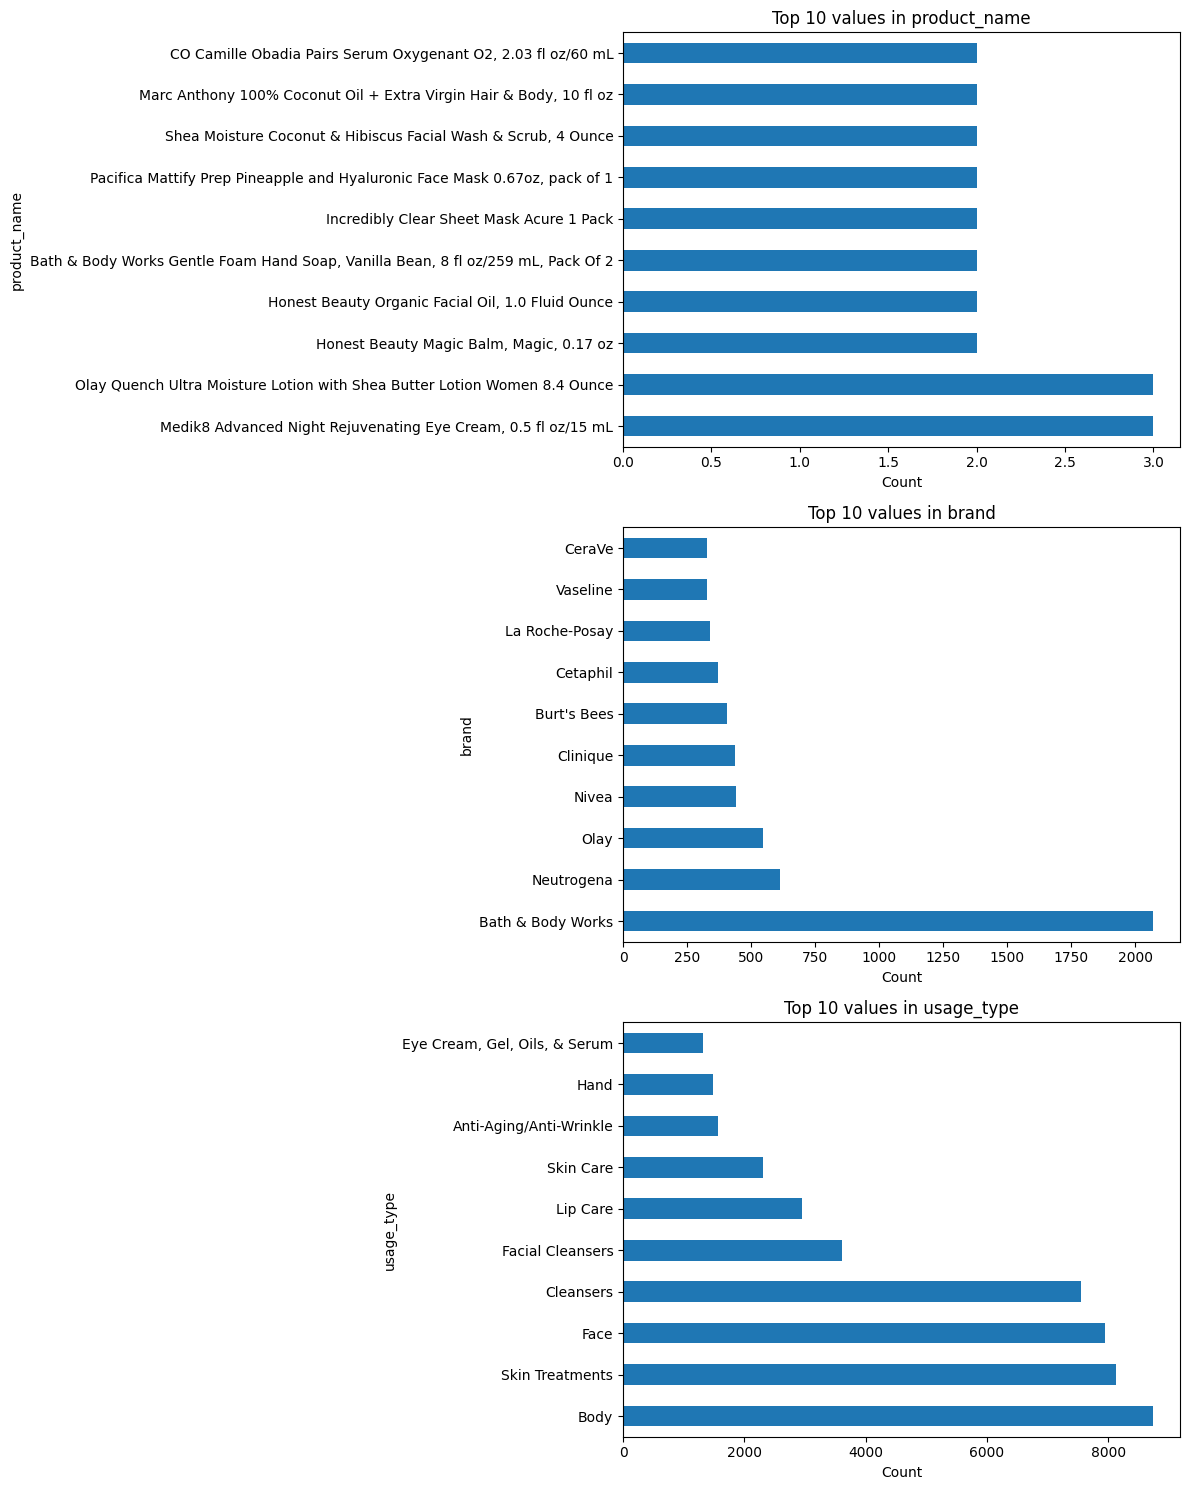

In [35]:
# Top categorical values visualizations
if len(categorical_cols) > 0:
    fig, axes = plt.subplots(min(3, len(categorical_cols)), 1, figsize=(12, 5 * min(3, len(categorical_cols))))
    if len(categorical_cols) == 1:
        axes = [axes]
    elif len(categorical_cols) <= 3:
        axes = list(axes)
    else:
        axes = list(axes[:3])
    
    for idx, col in enumerate(categorical_cols[:3]):
        top_values = df[col].value_counts().head(10)
        top_values.plot(kind='barh', ax=axes[idx])
        axes[idx].set_title(f'Top 10 values in {col}')
        axes[idx].set_xlabel('Count')
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns to visualize.")

### Missing Data Visualization

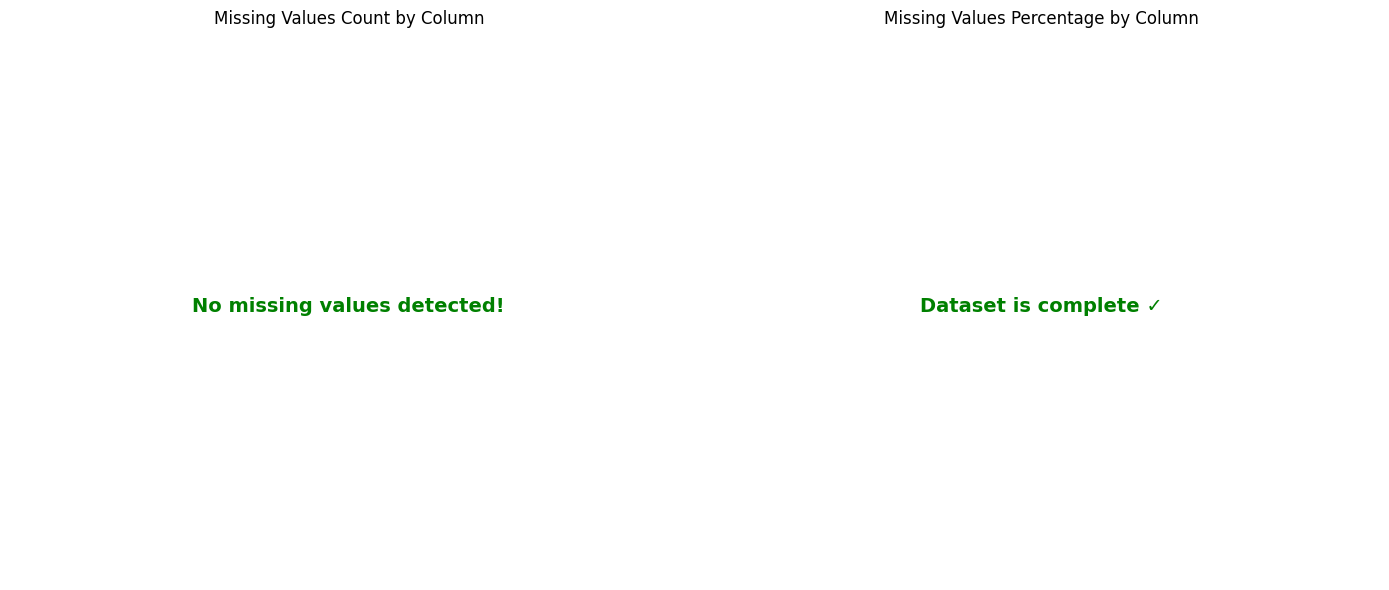

Total missing values: 0
Columns with missing data: 0


In [36]:
# Visualize missing data patterns
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_pct_data = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

missing_with_data = missing_data[missing_data > 0]
if len(missing_with_data) > 0:
    # Missing count bar chart
    missing_with_data.plot(kind='barh', ax=axes[0], color='coral')
    axes[0].set_title('Missing Values Count by Column')
    axes[0].set_xlabel('Count of Missing Values')
    
    # Missing percentage
    missing_pct_data[missing_pct_data > 0].plot(kind='barh', ax=axes[1], color='lightblue')
    axes[1].set_title('Missing Values Percentage by Column')
    axes[1].set_xlabel('Percentage (%)')
else:
    axes[0].text(0.5, 0.5, 'No missing values detected!', ha='center', va='center', 
                 fontsize=14, transform=axes[0].transAxes, color='green', fontweight='bold')
    axes[0].set_title('Missing Values Count by Column')
    axes[0].axis('off')
    
    axes[1].text(0.5, 0.5, 'Dataset is complete ✓', ha='center', va='center',
                 fontsize=14, transform=axes[1].transAxes, color='green', fontweight='bold')
    axes[1].set_title('Missing Values Percentage by Column')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Total missing values: {df.isnull().sum().sum():,}")
print(f"Columns with missing data: {(missing_data > 0).sum()}")

### Numerical Distribution Shape Analysis

In [37]:
from scipy import stats

if len(numeric_cols) > 0:
    print("=== Distribution Shape Analysis ===\n")
    
    distribution_info = []
    for col in numeric_cols:
        data = df[col].dropna()
        skewness = stats.skew(data)
        kurtosis_val = stats.kurtosis(data)
        
        # Determine distribution shape
        if abs(skewness) < 0.5:
            shape = "Approximately Symmetric"
        elif skewness > 0.5:
            shape = "Right-Skewed (positive tail)"
        else:
            shape = "Left-Skewed (negative tail)"
        
        distribution_info.append({
            'Column': col,
            'Skewness': f"{skewness:.3f}",
            'Kurtosis': f"{kurtosis_val:.3f}",
            'Shape': shape
        })
    
    dist_df = pd.DataFrame(distribution_info)
    display(dist_df)
else:
    print("No numeric columns available for distribution analysis.")

No numeric columns available for distribution analysis.


#### Distribution Shape Insights
Understanding distribution shapes is critical for model selection and feature engineering. Right-skewed distributions suggest that most products cluster at the lower end. Left-skewed features indicate the opposite. For machine learning models, highly skewed features often benefit from log transformation or scaling. 

### Categorical Value Distribution

In [38]:
# Analyze cardinality and class balance in categorical columns
print("=== Categorical Column Cardinality ===\n")

cardinality_info = []
for col in categorical_cols:
    unique_count = df[col].nunique()
    mode_val = df[col].mode()[0] if len(df[col].mode()) > 0 else "N/A"
    mode_freq = df[col].value_counts().iloc[0] if len(df[col].value_counts()) > 0 else 0
    mode_pct = (mode_freq / len(df) * 100) if len(df) > 0 else 0
    
    cardinality_info.append({
        'Column': col,
        'Unique Values': unique_count,
        'Most Common': str(mode_val)[:30],
        'Mode Frequency': mode_freq,
        'Mode %': f"{mode_pct:.1f}%"
    })

card_df = pd.DataFrame(cardinality_info)
display(card_df)

# High cardinality check
print("\nHigh cardinality columns (>100 unique values):")
for col in categorical_cols:
    if df[col].nunique() > 100:
        print(f"  - {col}: {df[col].nunique()} unique values")

=== Categorical Column Cardinality ===



,Column,Unique Values,Most Common,Mode Frequency,Mode %
0,product_name,50346,Medik8 Advanced Night Rejuvena,3,0.0%
1,brand,6959,Bath & Body Works,2072,4.1%
2,usage_type,21,Body,8745,17.2%
3,category,101,Creams,7388,14.5%
4,ingredients,44827,White Petrolatum,50,0.1%
5,image_url,50260,https://cdn.skinsafeproducts.c,89,0.2%
6,product_url,50348,https://www.skinsafeproducts.c,3,0.0%



High cardinality columns (>100 unique values):
  - product_name: 50346 unique values
  - brand: 6959 unique values
  - category: 101 unique values
  - ingredients: 44827 unique values
  - image_url: 50260 unique values
  - product_url: 50348 unique values


### Feature Correlations (if available)

In [39]:
if len(numeric_cols) > 1:
    # Compute correlation matrix
    corr_matrix = df[numeric_cols].corr()
    
    # Visualize correlations
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
    ax.set_title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()
    
    # Find high correlations
    print("\n=== High Correlations (|r| > 0.7) ===")
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                high_corr.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': f"{corr_matrix.iloc[i, j]:.3f}"
                })
    
    if high_corr:
        display(pd.DataFrame(high_corr))
    else:
        print("No strong correlations (>0.7) found between numeric features.")
elif len(numeric_cols) == 1:
    print(f"Only one numeric column available: {numeric_cols[0]}")
else:
    print("No numeric columns available for correlation analysis.")

No numeric columns available for correlation analysis.


### Overall Data Quality Summary

=== DATA QUALITY SCORECARD ===



,Metric,Value
0,Total Records,"50,969"
1,Total Columns,7
2,Data Completeness,100.0%
3,Duplicate Rows,621 (1.22%)
4,Numeric Columns,0
5,Categorical Columns,7
6,Missing Values,0
7,Quality Score,98.8/100


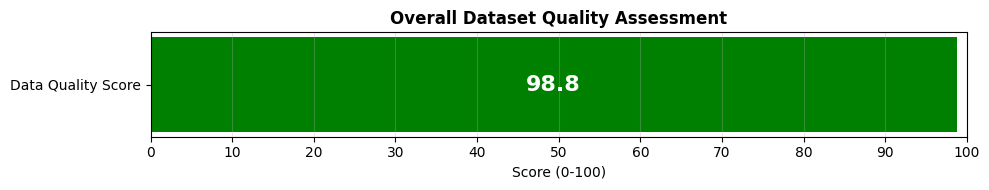

In [40]:
# Create data quality scorecard
print("=== DATA QUALITY SCORECARD ===\n")

total_cells = len(df) * len(df.columns)
null_cells = df.isnull().sum().sum()
completeness = ((total_cells - null_cells) / total_cells) * 100
duplicates = df.duplicated().sum()
duplicate_pct = (duplicates / len(df)) * 100 if len(df) > 0 else 0

quality_metrics = {
    'Metric': [
        'Total Records',
        'Total Columns',
        'Data Completeness',
        'Duplicate Rows',
        'Numeric Columns',
        'Categorical Columns',
        'Missing Values',
        'Quality Score'
    ],
    'Value': [
        f"{len(df):,}",
        f"{len(df.columns)}",
        f"{completeness:.1f}%",
        f"{duplicates} ({duplicate_pct:.2f}%)",
        f"{len(numeric_cols)}",
        f"{len(categorical_cols)}",
        f"{null_cells:,}",
        f"{max(0, 100 - (null_cells / total_cells * 100) - duplicate_pct):.1f}/100"
    ]
}

quality_df = pd.DataFrame(quality_metrics)
display(quality_df)

# Visual quality indicator
fig, ax = plt.subplots(figsize=(10, 2))
quality_score = max(0, 100 - (null_cells / total_cells * 100) - duplicate_pct)
colors = ['red' if quality_score < 70 else 'orange' if quality_score < 85 else 'green']
ax.barh(['Data Quality Score'], [quality_score], color=colors[0], height=0.3)
ax.set_xlim(0, 100)
ax.set_xlabel('Score (0-100)')
ax.text(quality_score / 2, 0, f'{quality_score:.1f}', va='center', ha='center', 
        fontsize=16, fontweight='bold', color='white')
ax.set_xticks(range(0, 101, 10))
ax.grid(axis='x', alpha=0.3)
plt.title('Overall Dataset Quality Assessment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### Data Quality Assessment
This scorecard synthesizes the dataset's readiness for machine learning. A high data quality score (>85) indicates minimal cleaning needed; a score below 70 suggests significant preprocessing work ahead. Our analysis reveals how well the dataset is structured: the completeness percentage tells us how many values are present vs. missing, duplication rates flag potential data collection errors, and the column breakdown shows the richness of features available. Datasets with strong quality scores enable models to learn robust patterns; poor quality often results in biased predictions. Based on these metrics, we set realistic expectations for model performance.

### Summary

In [41]:
print("\n=== Dataset Summary ===")
print(f"✓ Total entries: {len(df):,}")
print(f"✓ Total features: {len(df.columns)}")
print(f"✓ Memory footprint: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"✓ Completeness: {(1 - df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.2f}%")
print(f"✓ Duplicates: {df.duplicated().sum()} rows")

print("\n=== Next Steps ===")
print("1. Data cleaning & handling missing values")
print("2. Feature engineering (category, price range normalization)")
print("3. Ingredient tokenization & vectorization")
print("4. EDA visualizations for business insights")


=== Dataset Summary ===
✓ Total entries: 50,969
✓ Total features: 7
✓ Memory footprint: 55.81 MB
✓ Completeness: 100.00%
✓ Duplicates: 621 rows

=== Next Steps ===
1. Data cleaning & handling missing values
2. Feature engineering (category, price range normalization)
3. Ingredient tokenization & vectorization
4. EDA visualizations for business insights
